In [8]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

from sklearn.metrics import silhouette_score

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


Generate Motor Sensor Data

In [15]:
# Cell 2: Generate motor sensor data

np.random.seed(42)

# Normal operation
normal = np.random.normal(
    [35, 1.2],
    [1.5, 0.1],
    (30, 2)
)

# Warning state
warning = np.random.normal(
    [40, 1.5],
    [1.5, 0.1],
    (25, 2)
)

# Critical state
critical = np.random.normal(
    [46, 1.9],
    [2, 0.15],
    (20, 2)
)

# Combine all data
X = np.vstack([normal, warning, critical])

# True labels
y_true = np.array(
    [0]*30 + [1]*25 + [2]*20
)

print("✅ Data generated successfully")
print(f"Dataset shape: {X.shape}")
print(y_true)

✅ Data generated successfully
Dataset shape: (75, 2)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]


Display Dataset Information

In [13]:
# Cell 3: Dataset information

print("="*60)
print("🌳 HIERARCHICAL CLUSTERING - MOTOR SENSOR DATA")
print("="*60)

print(f"Total samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

print("\nFeatures:")
print("1. Temperature (°C)")
print("2. Current (A)")

print("\nTrue operating modes:")
print("0 → Normal")
print("1 → Warning")
print("2 → Critical")

🌳 HIERARCHICAL CLUSTERING - MOTOR SENSOR DATA
Total samples: 75
Total features: 2

Features:
1. Temperature (°C)
2. Current (A)

True operating modes:
0 → Normal
1 → Warning
2 → Critical


Visualize Raw Sensor Data

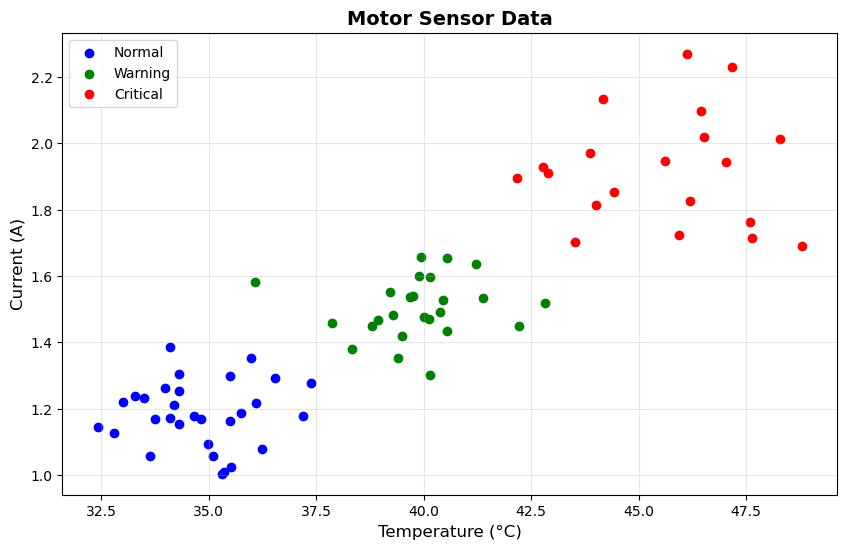

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    normal[:, 0],
    normal[:, 1],
    color='blue',
    label='Normal'
)

plt.scatter(
    warning[:, 0],
    warning[:, 1],
    color='green',
    label='Warning'
)

plt.scatter(
    critical[:, 0],
    critical[:, 1],
    color='red',
    label='Critical'
)

plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Current (A)', fontsize=12)

plt.title(
    'Motor Sensor Data',
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Perform Hierarchical Clustering

In [23]:
# what it does
# Index of first cluster merged, Index of second, Distance between them & Number of points in new cluster
Z = linkage(X, method='ward')

print("✅ Hierarchical clustering complete")
print(f"Linkage matrix shape: {Z.shape}")
print(Z)

✅ Hierarchical clustering complete
Linkage matrix shape: (74, 4)
[[6.00000000e+00 1.80000000e+01 4.98642716e-02 2.00000000e+00]
 [4.00000000e+00 2.30000000e+01 5.31356340e-02 2.00000000e+00]
 [6.00000000e+01 6.90000000e+01 6.59368289e-02 2.00000000e+00]
 [4.80000000e+01 5.40000000e+01 6.68789337e-02 2.00000000e+00]
 [3.30000000e+01 3.60000000e+01 7.80663207e-02 2.00000000e+00]
 [4.00000000e+01 5.20000000e+01 8.77049574e-02 2.00000000e+00]
 [1.20000000e+01 1.40000000e+01 9.34967907e-02 2.00000000e+00]
 [4.70000000e+01 5.10000000e+01 9.93063351e-02 2.00000000e+00]
 [7.00000000e+01 7.20000000e+01 1.02049446e-01 2.00000000e+00]
 [3.00000000e+01 4.40000000e+01 1.03162959e-01 2.00000000e+00]
 [6.50000000e+01 7.10000000e+01 1.14965605e-01 2.00000000e+00]
 [3.80000000e+01 4.90000000e+01 1.23069136e-01 2.00000000e+00]
 [1.10000000e+01 1.60000000e+01 1.26959379e-01 2.00000000e+00]
 [2.50000000e+01 2.90000000e+01 1.36488259e-01 2.00000000e+00]
 [5.00000000e+00 7.60000000e+01 1.46163106e-01 3.0000

Plot Dendrogram

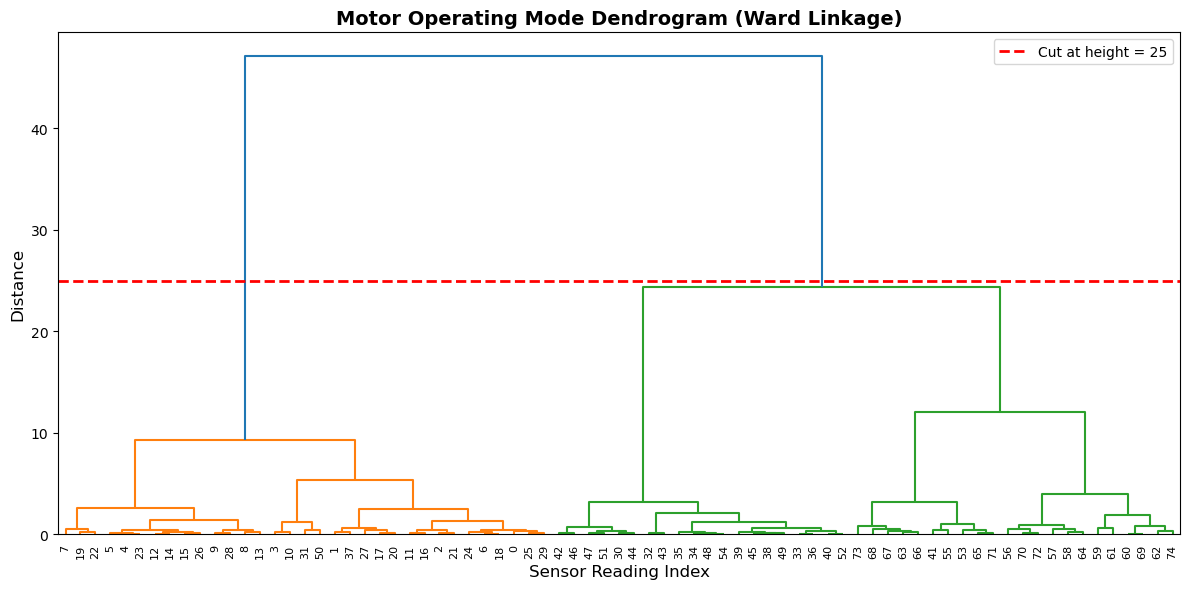

✅ Dendrogram saved as 'dendrogram.png'


In [27]:
# Cell 6: Plot dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.axhline(
    y=25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Cut at height = 25'
)

plt.xlabel(
    'Sensor Reading Index',
    fontsize=12
)

plt.ylabel(
    'Distance',
    fontsize=12
)

plt.title(
    'Motor Operating Mode Dendrogram (Ward Linkage)',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    'dendrogram.png',
    dpi=150
)

plt.show()

print("✅ Dendrogram saved as 'dendrogram.png'")

 Extract clusters

In [28]:
clusters = fcluster(
    Z,
    t=3,
    criterion='maxclust'
)

print("📊 Clustering Results")
print(f"Number of clusters found: {len(np.unique(clusters))}")

print("\nCluster labels:")
print(clusters)

📊 Clustering Results
Number of clusters found: 3

Cluster labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 2
 1 2 2 2 3 2 2 2 2 2 2 2 2 1 2 2 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3]


Evaluate clustering

In [31]:
# Measures how well-separated your clusters are.
# 0.7 – 1.0	Excellent clustering (tight groups, far apart)
# 0.5 – 0.7	Good clustering (reasonable separation)
# 0.2 – 0.5	Weak clustering (some overlap)
# < 0.2	Poor (points in wrong clusters)
# Formula: (b - a) / max(a, b)

# Close to +1 = Perfect (tight cluster, far from others)

# Close to 0 = Overlapping clusters

# Negative = Wrong cluster assignment

sil_score = silhouette_score(
    X,
    clusters
)

print(f"✅ Silhouette Score: {sil_score:.3f}")

✅ Silhouette Score: 0.613


Visualize clustering results

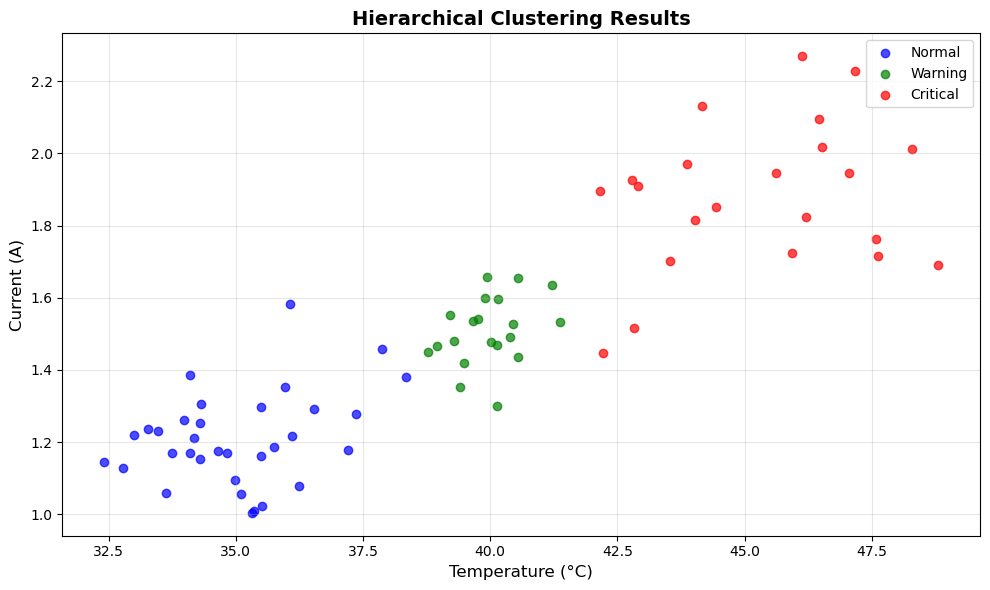

✅ Cluster visualization saved as 'clusters.png'


In [32]:


plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'red']
labels = ['Normal', 'Warning', 'Critical']

for i in range(1, 4):
    
    mask = clusters == i
    
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        c=colors[i-1],
        label=labels[i-1],
        alpha=0.7
    )

plt.xlabel(
    'Temperature (°C)',
    fontsize=12
)

plt.ylabel(
    'Current (A)',
    fontsize=12
)

plt.title(
    'Hierarchical Clustering Results',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'clusters.png',
    dpi=150
)

plt.show()

print("✅ Cluster visualization saved as 'clusters.png'")

In [35]:
#Final summary

print("\n✅ Analysis complete!")

print("\nGenerated files:")
print("1. dendrogram.png")
print("2. clusters.png")

print("\nProject finished successfully 🚀")


✅ Analysis complete!

Generated files:
1. dendrogram.png
2. clusters.png

Project finished successfully 🚀
